# 01 — Exploratory Data Analysis (EDA)

**Project:** Typing Weak-Finger ML (session-summary)

## Goals
1. Load and validate the raw dataset (`data/raw/sessions.csv`).
2. Check data quality (missing values, duplicates, ranges).
3. Explore distributions and label balance.
4. Validate label consistency (optional but recommended).
5. Save a cleaned dataset to `data/processed/dataset.csv` for training.

> Tip: Run this notebook from the project root (so relative paths work).


In [1]:
from pathlib import Path
import pandas as pd
import numpy  as np

# Plotting (optional but recommended)
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

# Paths (robust across JupyterLab/VSCode)
PROJECT_ROOT = Path("..")  # this notebook lives in /notebooks
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sessions.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "dataset.csv"

RAW_PATH, PROCESSED_PATH


(PosixPath('../data/raw/sessions.csv'),
 PosixPath('../data/processed/dataset.csv'))

In [2]:
# 1) Load data
if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at: {RAW_PATH}\n"
        f"Expected structure: project_root/data/raw/sessions.csv"
    )

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()


Shape: (80, 14)


,user_id,session_id,timestamp,wpm,accuracy,error_left_pinky,error_left_ring,error_left_middle,error_left_index,error_right_index,error_right_middle,error_right_ring,error_right_pinky,weakest_finger
0,u01,93e0c619-b22b-4a47-a041-75283bc6248d,2025-12-05T11:17:00,37.7,0.891,0.116,0.083,0.102,0.072,0.089,0.091,0.126,0.070,right_ring
1,u01,55f10bf7-7325-4b27-9eec-cfaea876a75e,2025-12-06T11:49:00,31.0,0.869,0.132,0.131,0.112,0.095,0.143,0.084,0.107,0.123,right_index
2,u01,e1870857-541e-4f34-b364-9bde04e70f3a,2025-12-07T10:15:00,35.2,0.884,0.101,0.120,0.114,0.096,0.172,0.128,0.080,0.073,right_index
3,u01,eb8e0246-bac7-4d3b-a2c7-4cab52281c84,2025-12-08T11:48:00,22.0,0.906,0.057,0.148,0.074,0.081,0.109,0.105,0.097,0.076,left_ring
4,u01,67f2c9fb-4496-4b84-a82e-3d7fea621e69,2025-12-09T09:27:00,26.5,0.894,0.069,0.123,0.083,0.099,0.085,0.091,0.113,0.108,left_ring


In [3]:
# 2) Basic overview
print("Columns:", list(df.columns))
display(df.head(3))
display(df.describe(include="all").T)


Columns: ['user_id', 'session_id', 'timestamp', 'wpm', 'accuracy', 'error_left_pinky', 'error_left_ring', 'error_left_middle', 'error_left_index', 'error_right_index', 'error_right_middle', 'error_right_ring', 'error_right_pinky', 'weakest_finger']


,user_id,session_id,timestamp,wpm,accuracy,error_left_pinky,error_left_ring,error_left_middle,error_left_index,error_right_index,error_right_middle,error_right_ring,error_right_pinky,weakest_finger
0,u01,93e0c619-b22b-4a47-a041-75283bc6248d,2025-12-05T11:17:00,37.7,0.891,0.116,0.083,0.102,0.072,0.089,0.091,0.126,0.070,right_ring
1,u01,55f10bf7-7325-4b27-9eec-cfaea876a75e,2025-12-06T11:49:00,31.0,0.869,0.132,0.131,0.112,0.095,0.143,0.084,0.107,0.123,right_index
2,u01,e1870857-541e-4f34-b364-9bde04e70f3a,2025-12-07T10:15:00,35.2,0.884,0.101,0.120,0.114,0.096,0.172,0.128,0.080,0.073,right_index


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,80,4,u01,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,80,80,93e0c619-b22b-4a47-a041-75283bc6248d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,80,79,2025-12-23T10:39:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wpm,80.0,NaN,NaN,NaN,57.555,15.502641,22.0,52.575,64.4,67.8,81.0
accuracy,80.0,NaN,NaN,NaN,0.911938,0.030595,0.865,0.89,0.9025,0.932,0.977
error_left_pinky,80.0,NaN,NaN,NaN,0.084,0.037414,0.017,0.0665,0.08,0.10125,0.19
error_left_ring,80.0,NaN,NaN,NaN,0.08235,0.037221,0.012,0.06,0.0805,0.106,0.214
error_left_middle,80.0,NaN,NaN,NaN,0.085375,0.041317,0.016,0.05975,0.0795,0.105,0.227
error_left_index,80.0,NaN,NaN,NaN,0.083125,0.035294,0.015,0.05875,0.0835,0.10325,0.188
error_right_index,80.0,NaN,NaN,NaN,0.083113,0.039043,0.019,0.06025,0.079,0.10475,0.203


In [4]:
# 3) Missing values + duplicates
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("Duplicate rows:", df.duplicated().sum())
if "session_id" in df.columns:
    print("Duplicate session_id:", df["session_id"].duplicated().sum())


Series([], dtype: int64)

Duplicate rows: 0
Duplicate session_id: 0


In [5]:
# 4) Domain sanity checks (edit thresholds as needed)
# For session-summary data:
# - wpm should be within a reasonable range
# - accuracy should be in [0, 1]

before = len(df)

df = df.drop_duplicates()

if "wpm" in df.columns:
    df = df[df["wpm"].between(0, 250)]

if "accuracy" in df.columns:
    df = df[df["accuracy"].between(0, 1)]

after = len(df)
print(f"Rows before: {before}, after cleaning: {after}, removed: {before-after}")


Rows before: 80, after cleaning: 80, removed: 0


weakest_finger
right_ring      10
right_index     10
left_ring       10
left_index      10
right_pinky     10
left_pinky      10
left_middle     10
right_middle    10
Name: count, dtype: int64

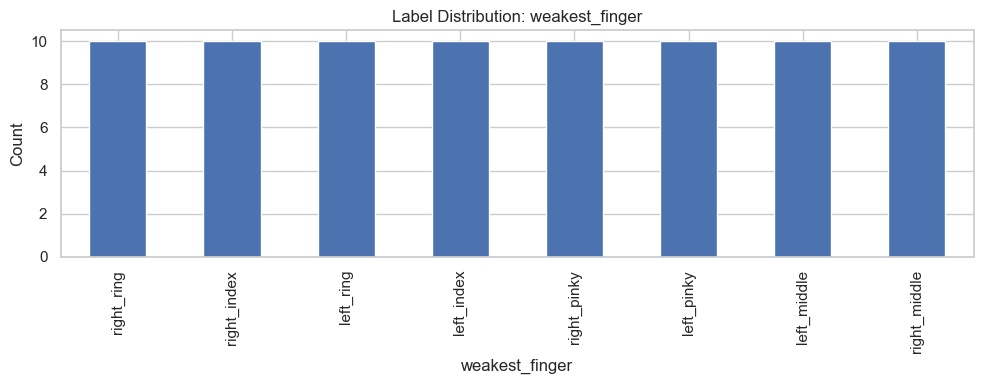

In [6]:
# 5) Label distribution (classification target)
label_col = "weakest_finger"
if label_col not in df.columns:
    raise ValueError(f"Missing target column: {label_col}")

display(df[label_col].value_counts())

plt.figure(figsize=(10, 4))
df[label_col].value_counts().plot(kind="bar")
plt.title("Label Distribution: weakest_finger")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


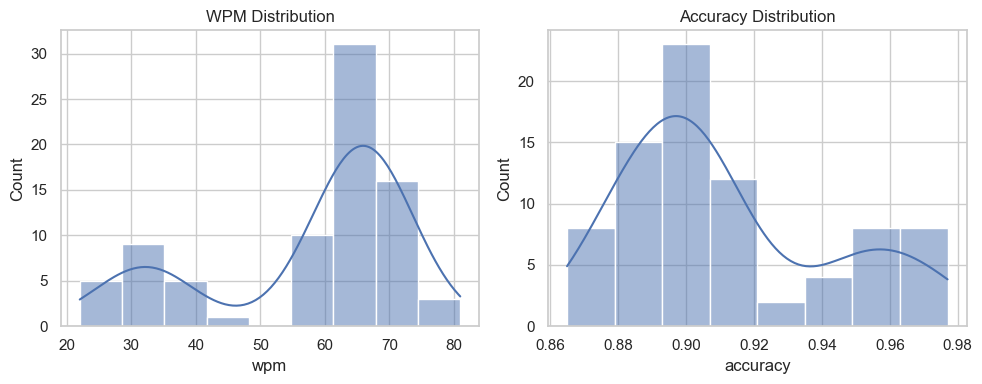

In [7]:
# 6) Distribution plots for key metrics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if sns:
    sns.histplot(df["wpm"], kde=True, ax=axes[0])
    sns.histplot(df["accuracy"], kde=True, ax=axes[1])
else:
    axes[0].hist(df["wpm"].dropna(), bins=20)
    axes[1].hist(df["accuracy"].dropna(), bins=20)

axes[0].set_title("WPM Distribution")
axes[0].set_xlabel("wpm")
axes[1].set_title("Accuracy Distribution")
axes[1].set_xlabel("accuracy")

plt.tight_layout()
plt.show()


In [8]:
# 7) Finger error columns sanity
error_cols = [c for c in df.columns if c.startswith("error_")]
print("Number of error_* columns:", len(error_cols))
print("error_* columns:", error_cols)

if error_cols:
    stats = df[error_cols].describe().T[["min", "max", "mean", "std"]]
    display(stats)

    bad = (df[error_cols] < 0).any(axis=1) | (df[error_cols] > 1).any(axis=1)
    print("Rows with invalid error_* range (<0 or >1):", int(bad.sum()))
else:
    print("No error_* columns found. If you only have WPM/accuracy, skip this section.")


Number of error_* columns: 8
error_* columns: ['error_left_pinky', 'error_left_ring', 'error_left_middle', 'error_left_index', 'error_right_index', 'error_right_middle', 'error_right_ring', 'error_right_pinky']


,min,max,mean,std
error_left_pinky,0.017,0.190,0.084000,0.037414
error_left_ring,0.012,0.214,0.082350,0.037221
error_left_middle,0.016,0.227,0.085375,0.041317
error_left_index,0.015,0.188,0.083125,0.035294
error_right_index,0.019,0.203,0.083113,0.039043
error_right_middle,0.020,0.191,0.083888,0.037815
error_right_ring,0.014,0.215,0.083900,0.039503
error_right_pinky,0.005,0.201,0.084937,0.040955


Rows with invalid error_* range (<0 or >1): 0


In [9]:
# 8) Optional consistency check:
# Does weakest_finger match the finger with the maximum error_* in that row?
# This is especially useful if your label is derived from max error.

if error_cols:
    def inferred_weakest(row):
        max_col = row[error_cols].idxmax()
        return max_col.replace("error_", "")

    df["weakest_inferred"] = df.apply(inferred_weakest, axis=1)
    mismatch_rate = (df["weakest_inferred"] != df["weakest_finger"]).mean()
    print("Mismatch rate (inferred vs label):", round(float(mismatch_rate), 4))

    # Show a few mismatches (if any)
    mismatches = df[df["weakest_inferred"] != df["weakest_finger"]]
    display(mismatches[["weakest_finger", "weakest_inferred"] + error_cols].head(10))
else:
    print("Skip: no error_* columns.")


Mismatch rate (inferred vs label): 0.0


,weakest_finger,weakest_inferred,error_left_pinky,error_left_ring,error_left_middle,error_left_index,error_right_index,error_right_middle,error_right_ring,error_right_pinky


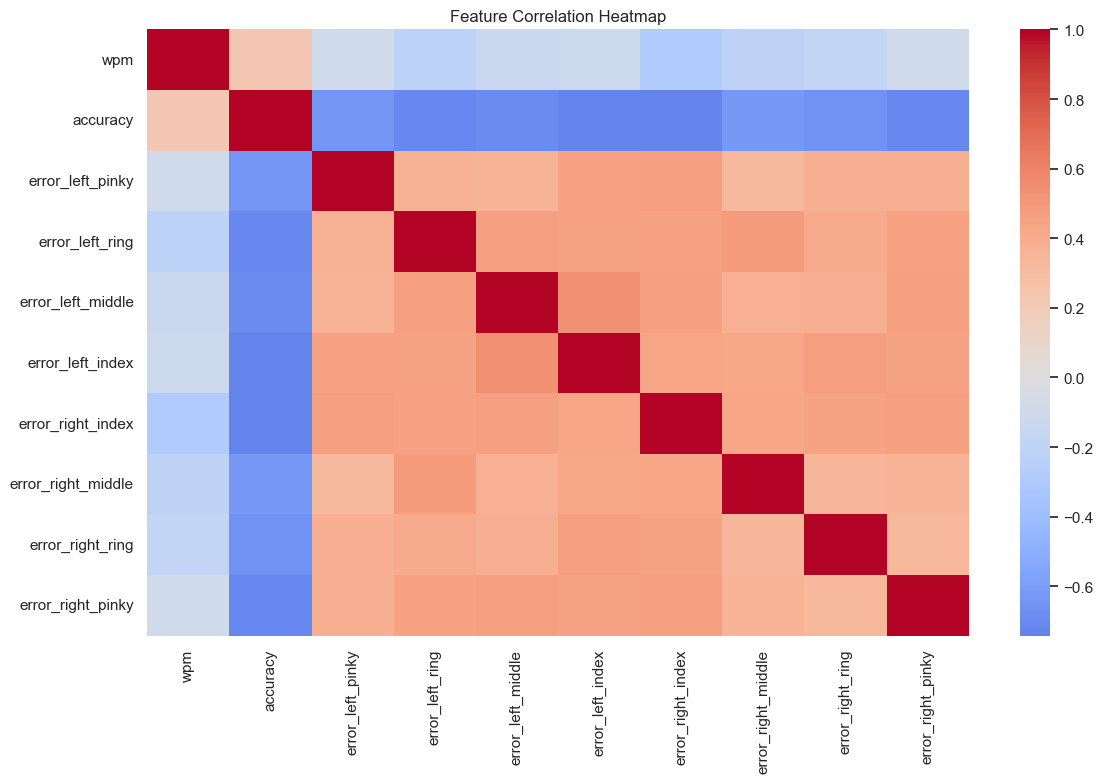

In [10]:
# 9) Correlation heatmap (numeric features)
# Helps you see redundancy and relationships.

num_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
if sns:
    sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
else:
    plt.imshow(num_df.corr(), cmap="coolwarm")
    plt.colorbar()

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [11]:
# 10) Save processed dataset
# IMPORTANT: Remove helper columns before training if you don't want them as features.

for c in ["weakest_inferred"]:
    if c in df.columns:
        df = df.drop(columns=[c])

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print("Saved processed dataset to:", PROCESSED_PATH)
print("Processed shape:", df.shape)


Saved processed dataset to: ../data/processed/dataset.csv
Processed shape: (80, 14)
